In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np

print("Working directory:", Path.cwd())

candidate_dirs = [
    Path("C://Users/asus/OneDrive/Documents/Network Intrusion Detector dataset"),
    Path("Network Intrusion Detector dataset"),
]

DATA_DIR = next((p for p in candidate_dirs if p.exists()), None)

if DATA_DIR is None:
    raise FileNotFoundError(
        "CICIoT2023 dataset folder not found. "
        "Place it at data/CICIoT2023/ or Network Intrusion Detector dataset/."
    )

print("Dataset directory:", DATA_DIR.resolve())

Working directory: C:\Users\asus\OneDrive\Documents\Network Intrusion Detector
Dataset directory: C:\Users\asus\OneDrive\Documents\Network Intrusion Detector dataset


In [2]:
BENIGN_FILE = "BenignTraffic.pcap.csv"

DDOS_FILES = [
    "DDoS-ACK_Fragmentation.pcap.csv",
    "DDoS-HTTP_Flood-.pcap.csv",
    "DDoS-ICMP_Flood.pcap.csv",
    "DDoS-ICMP_Fragmentation.pcap.csv",
    "DDoS-PSHACK_Flood.pcap.csv",
    "DDoS-RSTFINFlood.pcap.csv",
    "DDoS-SYN_Flood.pcap.csv",
    "DDoS-SlowLoris.pcap.csv",
    "DDoS-SynonymousIP_Flood.pcap.csv",
    "DDoS-TCP_Flood.pcap.csv",
    "DDoS-UDP_Flood.pcap.csv",
    "DDoS-UDP_Fragmentation.pcap.csv",
]

ALL_FILES = [BENIGN_FILE] + DDOS_FILES

missing_files = [f for f in ALL_FILES if not (DATA_DIR / f).exists()]

if missing_files:
    raise FileNotFoundError(
        "Missing dataset files:\n" + "\n".join(missing_files)
    )

print(f"Found {len(ALL_FILES)} required CSV files.")

Found 13 required CSV files.


In [3]:
# Inspect the structure of the downloaded CSV files.
# This does not load the full dataset.

inventory = []

for filename in ALL_FILES:
    path = DATA_DIR / filename
    sample = pd.read_csv(path, nrows=5)

    row_count = sum(1 for _ in open(path, encoding="utf-8")) - 1

    inventory.append({
        "file": filename,
        "rows": row_count,
        "columns": sample.shape[1],
        "size_MB": round(path.stat().st_size / (1024**2), 2),
    })

inventory_df = pd.DataFrame(inventory)
display(inventory_df)

print("\nTotal available rows:", f"{inventory_df['rows'].sum():,}")

,file,rows,columns,size_MB
0,BenignTraffic.pcap.csv,362361,39,71.62
1,DDoS-ACK_Fragmentation.pcap.csv,25090,39,5.27
2,DDoS-HTTP_Flood-.pcap.csv,28790,39,6.15
3,DDoS-ICMP_Flood.pcap.csv,268010,39,47.33
4,DDoS-ICMP_Fragmentation.pcap.csv,20696,39,4.36
5,DDoS-PSHACK_Flood.pcap.csv,267811,39,48.04
6,DDoS-RSTFINFlood.pcap.csv,266934,39,48.49
7,DDoS-SYN_Flood.pcap.csv,266024,39,48.74
8,DDoS-SlowLoris.pcap.csv,23426,39,4.98
9,DDoS-SynonymousIP_Flood.pcap.csv,268626,39,47.73



Total available rows: 2,352,691


In [4]:
RANDOM_STATE = 42

BENIGN_SAMPLE_SIZE = 350_000
DDOS_SAMPLE_SIZE_PER_TYPE = 75_000

print("Benign sample target:", f"{BENIGN_SAMPLE_SIZE:,}")
print("DDoS sample target per subtype:", f"{DDOS_SAMPLE_SIZE_PER_TYPE:,}")

Benign sample target: 350,000
DDoS sample target per subtype: 75,000


In [5]:
def attack_name_from_filename(filename):
    if filename == BENIGN_FILE:
        return "BenignTraffic"
    return Path(filename).name.replace(".pcap.csv", "").replace("-", "-", 1)


def load_and_sample(filename, target_rows, binary_label, attack_type):
    path = DATA_DIR / filename

    df = pd.read_csv(path)

    # Clean column names without changing their meaning.
    df.columns = df.columns.str.strip()

    # Replace +/- infinity before modeling.
    df = df.replace([np.inf, -np.inf], np.nan)

    if target_rows < len(df):
        df = df.sample(
            n=target_rows,
            random_state=RANDOM_STATE
        )

    df["attack_type"] = attack_type
    df["binary_label"] = binary_label

    return df


benign_df = load_and_sample(
    BENIGN_FILE,
    BENIGN_SAMPLE_SIZE,
    binary_label=0,
    attack_type="BenignTraffic"
)

ddos_frames = []

for filename in DDOS_FILES:
    attack_type = Path(filename).name.replace(".pcap.csv", "")
    df = load_and_sample(
        filename,
        DDOS_SAMPLE_SIZE_PER_TYPE,
        binary_label=1,
        attack_type=attack_type
    )
    ddos_frames.append(df)

ddos_df = pd.concat(ddos_frames, ignore_index=True)

dataset = pd.concat(
    [benign_df, ddos_df],
    ignore_index=True
)

# Shuffle once after combining all classes.
dataset = dataset.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

print("Prepared dataset shape:", dataset.shape)

Prepared dataset shape: (995544, 41)


In [6]:
print("Binary class distribution:")
print(dataset["binary_label"].value_counts().sort_index())

print("\nBinary class percentages:")
print(
    (dataset["binary_label"].value_counts(normalize=True).sort_index() * 100)
    .round(2)
)

print("\nAttack subtype distribution:")
display(
    dataset["attack_type"]
    .value_counts()
    .rename_axis("attack_type")
    .reset_index(name="records")
)

Binary class distribution:
binary_label
0    350000
1    645544
Name: count, dtype: int64

Binary class percentages:
binary_label
0    35.16
1    64.84
Name: proportion, dtype: float64

Attack subtype distribution:


,attack_type,records
0,BenignTraffic,350000
1,DDoS-RSTFINFlood,75000
2,DDoS-SynonymousIP_Flood,75000
3,DDoS-SYN_Flood,75000
4,DDoS-ICMP_Flood,75000
5,DDoS-PSHACK_Flood,75000
6,DDoS-UDP_Flood,75000
7,DDoS-TCP_Flood,75000
8,DDoS-HTTP_Flood-,28790
9,DDoS-ACK_Fragmentation,25090


In [7]:
TARGET = "binary_label"

X = dataset.drop(columns=["binary_label", "attack_type"])
y = dataset[TARGET]

print("Feature matrix:", X.shape)
print("Target vector:", y.shape)
print("\nFeature columns:")
print(list(X.columns))

Feature matrix: (995544, 39)
Target vector: (995544,)

Feature columns:
['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance']


In [8]:
print("Number of features:", X.shape[1])
print("Data types:")
display(X.dtypes.value_counts())

print("\nMissing values:")
missing_summary = X.isna().sum().sort_values(ascending=False)
display(missing_summary[missing_summary > 0].head(15))

print("\nInfinite values remaining:", np.isinf(X.select_dtypes(include=np.number)).sum().sum())

Number of features: 39
Data types:


float64    30
int64       9
Name: count, dtype: int64


Missing values:


Rate        34
Variance    29
Std         29
dtype: int64


Infinite values remaining: 0


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).sort_index().mul(100).round(2))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).sort_index().mul(100).round(2))

X_train: (796435, 39)
X_test : (199109, 39)
y_train: (796435,)
y_test : (199109,)

Training class distribution:
binary_label
0    35.16
1    64.84
Name: proportion, dtype: float64

Testing class distribution:
binary_label
0    35.16
1    64.84
Name: proportion, dtype: float64


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_features = X_train.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_features
        )
    ],
    remainder="drop"
)

print("Numeric features:", len(numeric_features))
print("Preprocessor created successfully.")

Numeric features: 39
Preprocessor created successfully.


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

print("Baseline Random Forest pipeline created.")

Baseline Random Forest pipeline created.


In [12]:
rf_model.fit(X_train, y_train)

print("Baseline Random Forest training completed.")

Baseline Random Forest training completed.


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_precision = precision_score(y_test, y_pred, zero_division=0)
baseline_recall = recall_score(y_test, y_pred, zero_division=0)
baseline_f1 = f1_score(y_test, y_pred, zero_division=0)
baseline_roc_auc = roc_auc_score(y_test, y_prob)

print("Baseline Random Forest Results")
print("------------------------------")
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")
print(f"ROC-AUC  : {baseline_roc_auc:.4f}")

Baseline Random Forest Results
------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000


In [14]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "DDoS"],
        digits=4,
        zero_division=0
    )
)

cm_baseline = confusion_matrix(y_test, y_pred)

print("Baseline Confusion Matrix:")
print(cm_baseline)

              precision    recall  f1-score   support

      Benign     1.0000    1.0000    1.0000     70000
        DDoS     1.0000    1.0000    1.0000    129109

    accuracy                         1.0000    199109
   macro avg     1.0000    1.0000    1.0000    199109
weighted avg     1.0000    1.0000    1.0000    199109

Baseline Confusion Matrix:
[[ 69999      1]
 [     2 129107]]


In [15]:
rf_weighted = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_weighted.fit(X_train, y_train)

y_pred_weighted = rf_weighted.predict(X_test)
y_prob_weighted = rf_weighted.predict_proba(X_test)[:, 1]

weighted_accuracy = accuracy_score(y_test, y_pred_weighted)
weighted_precision = precision_score(y_test, y_pred_weighted, zero_division=0)
weighted_recall = recall_score(y_test, y_pred_weighted, zero_division=0)
weighted_f1 = f1_score(y_test, y_pred_weighted, zero_division=0)
weighted_roc_auc = roc_auc_score(y_test, y_prob_weighted)

print("Class-Weighted Random Forest Results")
print("------------------------------------")
print(f"Accuracy : {weighted_accuracy:.4f}")
print(f"Precision: {weighted_precision:.4f}")
print(f"Recall   : {weighted_recall:.4f}")
print(f"F1 Score : {weighted_f1:.4f}")
print(f"ROC-AUC  : {weighted_roc_auc:.4f}")

Class-Weighted Random Forest Results
------------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000


In [16]:
print(
    classification_report(
        y_test,
        y_pred_weighted,
        target_names=["Benign", "DDoS"],
        digits=4,
        zero_division=0
    )
)

cm_weighted = confusion_matrix(y_test, y_pred_weighted)
print("Class-Weighted Confusion Matrix:")
print(cm_weighted)

              precision    recall  f1-score   support

      Benign     1.0000    1.0000    1.0000     70000
        DDoS     1.0000    1.0000    1.0000    129109

    accuracy                         1.0000    199109
   macro avg     1.0000    1.0000    1.0000    199109
weighted avg     1.0000    1.0000    1.0000    199109

Class-Weighted Confusion Matrix:
[[ 69999      1]
 [     3 129106]]


In [17]:
from sklearn.model_selection import RandomizedSearchCV

rf_tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

param_grid = {
    "classifier__n_estimators": [100, 150, 200],
    "classifier__max_depth": [None, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"],
    "classifier__class_weight": [None, "balanced"],
}

random_search = RandomizedSearchCV(
    estimator=rf_tuning_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="f1",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2
)

print("RandomizedSearchCV created.")
print("This step can take a significant amount of time on a ~1M-row dataset.")

RandomizedSearchCV created.
This step can take a significant amount of time on a ~1M-row dataset.


In [18]:
print("Starting hyperparameter search...")

random_search.fit(
    X_train,
    y_train
)

print("Hyperparameter search complete.")

Starting hyperparameter search...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Hyperparameter search complete.


In [19]:
print("Best Hyperparameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(f"{random_search.best_score_:.4f}")

Best Hyperparameters:
{'classifier__n_estimators': 100, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 30, 'classifier__class_weight': None}

Best Cross-Validation F1 Score:
1.0000


In [20]:
best_model = random_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned, zero_division=0)
tuned_recall = recall_score(y_test, y_pred_tuned, zero_division=0)
tuned_f1 = f1_score(y_test, y_pred_tuned, zero_division=0)
tuned_roc_auc = roc_auc_score(y_test, y_prob_tuned)

print("Tuned Random Forest Results")
print("---------------------------")
print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1 Score : {tuned_f1:.4f}")
print(f"ROC-AUC  : {tuned_roc_auc:.4f}")

Tuned Random Forest Results
---------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000


In [21]:
print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=["Benign", "DDoS"],
        digits=4,
        zero_division=0
    )
)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print("Tuned Confusion Matrix:")
print(cm_tuned)

              precision    recall  f1-score   support

      Benign     1.0000    1.0000    1.0000     70000
        DDoS     1.0000    1.0000    1.0000    129109

    accuracy                         1.0000    199109
   macro avg     1.0000    1.0000    1.0000    199109
weighted avg     1.0000    1.0000    1.0000    199109

Tuned Confusion Matrix:
[[ 69999      1]
 [     2 129107]]


In [22]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Class-Weighted Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        weighted_accuracy,
        tuned_accuracy
    ],
    "Precision": [
        baseline_precision,
        weighted_precision,
        tuned_precision
    ],
    "Recall": [
        baseline_recall,
        weighted_recall,
        tuned_recall
    ],
    "F1 Score": [
        baseline_f1,
        weighted_f1,
        tuned_f1
    ],
    "ROC-AUC": [
        baseline_roc_auc,
        weighted_roc_auc,
        tuned_roc_auc
    ]
})

display(model_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Random Forest,1.0,1.0,1.0,1.0,1.0
1,Class-Weighted Random Forest,1.0,1.0,1.0,1.0,1.0
2,Tuned Random Forest,1.0,1.0,1.0,1.0,1.0


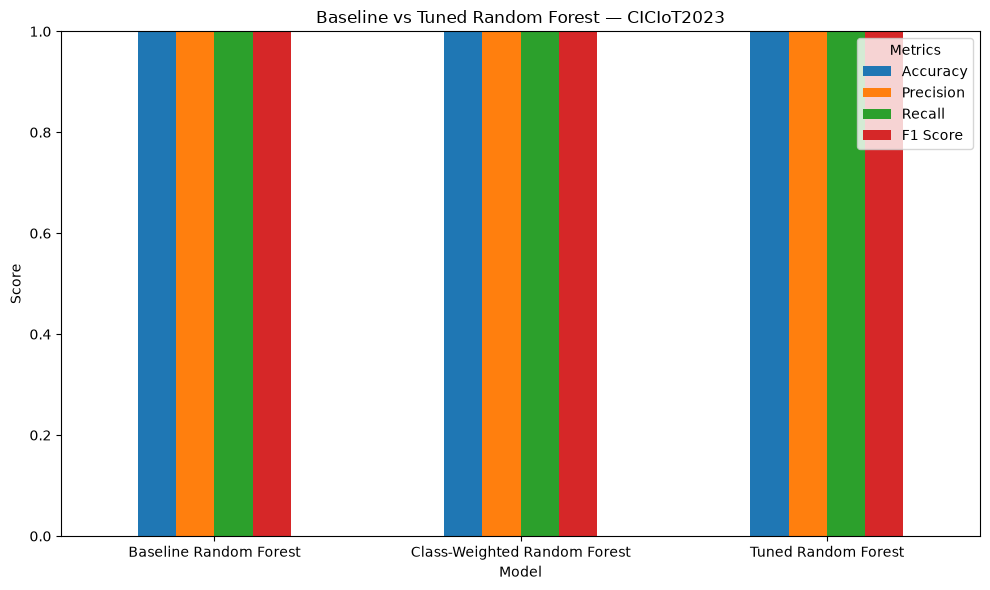

In [23]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

model_comparison.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Baseline vs Tuned Random Forest — CICIoT2023")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

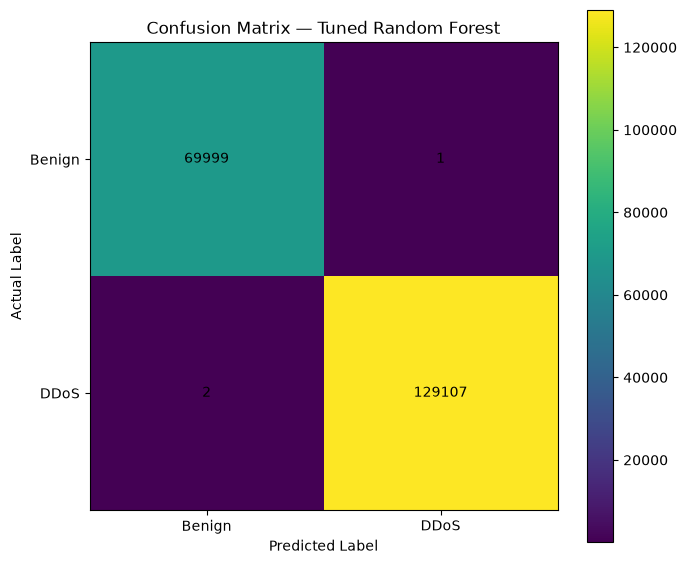

In [24]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7, 6))

plt.imshow(cm_tuned, interpolation="nearest")
plt.title("Confusion Matrix — Tuned Random Forest")
plt.colorbar()

classes = ["Benign", "DDoS"]

plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(cm_tuned.shape[0]):
    for j in range(cm_tuned.shape[1]):
        plt.text(
            j,
            i,
            format(cm_tuned[i, j], "d"),
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [25]:
test_indices = X_test.index

subtype_results = dataset.loc[test_indices, ["attack_type", "binary_label"]].copy()
subtype_results["prediction"] = np.asarray(y_pred_tuned)
subtype_results["correct"] = (
    subtype_results["binary_label"] == subtype_results["prediction"]
)

subtype_accuracy = (
    subtype_results
    .groupby("attack_type")["correct"]
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
    .rename("accuracy_percent")
    .reset_index()
)

display(subtype_accuracy)

,attack_type,accuracy_percent
0,DDoS-ACK_Fragmentation,100.00
1,DDoS-ICMP_Flood,100.00
2,DDoS-HTTP_Flood-,100.00
3,DDoS-ICMP_Fragmentation,100.00
4,DDoS-PSHACK_Flood,100.00
5,DDoS-UDP_Flood,100.00
6,DDoS-RSTFINFlood,100.00
7,DDoS-SYN_Flood,100.00
8,DDoS-SynonymousIP_Flood,100.00
9,DDoS-UDP_Fragmentation,100.00


In [26]:
SAVE_PREPARED_DATA = False

if SAVE_PREPARED_DATA:
    output_path = DATA_DIR / "CICIoT2023_DDoS_Binary_Sampled.csv"
    dataset.to_csv(output_path, index=False)
    print("Saved:", output_path.resolve())
else:
    print("Saving disabled.")

Saving disabled.
